# JEPADepth &mdash; Inference & Depth Estimation



This notebook demonstrates the **core inference functionality** of JEPADepth: taking a single RGB image and predicting a dense monocular depth map with a self-supervised network.
JEPADepth couples a **DINOv3 ViT context encoder** with an **FPN-style multi-scale depth decoder**, trained self-supervised on KITTI video with an added **I-JEPA masked-prediction objective** (see notebook `jepadepth_internals_and_jepa_masking.ipynb`).



What you will do here:

1. Load the trained JEPADepth model from the config.

2. Run inference on a single image and visualize *normalized disparity &rarr; disparity &rarr; depth*.

3. Run a batch over the sample image folder as a gallery.

4. Compare JEPADepth against the MonoDepth2 baseline side-by-side.


> **Scale ambiguity:** self-supervised monocular depth is *scale-ambiguous*. The predicted depth is up to an unknown global scale factor &mdash; for metric depth you median-scale against ground truth (done in the evaluation scripts), or apply the KITTI stereo-baseline factor.

## 1. Setup

Move to the repo root so `import src...` and the relative weight paths in `config.yaml` resolve.

In [2]:
import os, sys

# Make the notebook run from the repository root regardless of where Jupyter was started.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)
print("Working directory:", os.getcwd())

Working directory: /data/backup_gpu2/home/ionut/JEPADepth


In [3]:
import time
import glob
import numpy as np
import torch
import PIL.Image as pil
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from torchvision import transforms

from src.config.conf import Conf
from src.models.dinov3.dino import DINODepth
from src.models.monodepth2.monodepth2 import MonoDepth2
from src.utils import disp_to_depth, count_parameters, format_number

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


/home/ionut/miniconda3/envs/dino/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load configuration

Everything (model paths, resolution, depth range) lives in `src/config/config.yaml`.

In [4]:
conf = Conf().conf
IM_H, IM_W = conf["im_sz"]     
MIN_DEPTH  = conf["min_depth"]
MAX_DEPTH  = conf["max_depth"]

print(f"Input resolution : {IM_W} x {IM_H} (WxH)")
print(f"Depth range      : [{MIN_DEPTH}, {MAX_DEPTH}]")
print(f"DINO decoder     : {conf['dino']['decoder_type']}")
print(f"Encoder weights  : {conf['dino']['encoder_weights_path']}")
print(f"Decoder weights  : {conf['dino']['decoder_weights_path']}")

Input resolution : 640 x 192 (WxH)
Depth range      : [0.1, 100.0]
DINO decoder     : fpn
Encoder weights  : tensorboard/train/jepa_small/20260220-112633/models/weights_epoch_19/context_encoder.pth
Decoder weights  : tensorboard/train/jepa_small/20260220-112633/models/weights_epoch_19/depth_decoder.pth


## 3. Build & load the JEPADepth model



`DINODepth` = DINOv3 ViT encoder + a multi-scale decoder (`fpn` here). For a JEPA-trained model the context encoder and depth decoder are saved as **separate** checkpoints, so we pass both paths to `from_pretrained`. (A non-JEPA model saved as one file would use the `weights_path` argument instead.)

In [5]:
dc = conf["dino"]
model = DINODepth(encoder_size=dc["encoder_size"], decoder_channels=dc["decoder_channels"], scales=dc["scales"], decoder_type=dc["decoder_type"])
model.from_pretrained(encoder_weights_path=dc["encoder_weights_path"], decoder_weights_path=dc["decoder_weights_path"], weights_path=None, device=device)
model.to(device).eval()

total_params, trainable = count_parameters(model)
print(f"JEPADepth loaded  |  parameters: {format_number(total_params)}  (trainable: {format_number(trainable)})")

JEPADepth loaded  |  parameters: 24.37M  (trainable: 24.37M)


## 4. Inference helpers



The decoder ends in a **sigmoid** producing *normalized disparity* in `[0, 1]`. We convert it with `disp_to_depth` (the standard Monodepth2 formula):



```

min_disp  = 1 / max_depth ;  max_disp = 1 / min_depth
disparity = min_disp + (max_disp - min_disp) * sigmoid_output
depth     = 1 / disparity

```

In [6]:
def load_image(path, h=IM_H, w=IM_W):
    """Load an RGB image, remember original size, return a normalized [1,3,h,w] tensor."""
    img = pil.open(path).convert("RGB")
    orig_w, orig_h = img.size
    img_resized = img.resize((w, h), pil.Resampling.LANCZOS)
    tensor = transforms.ToTensor()(img_resized).unsqueeze(0)
    return img_resized, tensor, (orig_w, orig_h)

@torch.no_grad()
def predict(model, tensor):
    """Return (normalized_disp, disparity, depth) numpy maps at model resolution."""
    tensor = tensor.to(device)
    norm_disp = model(tensor)[("disp", 0)]                       # sigmoid output, [1,1,H,W]
    disparity, depth = disp_to_depth(norm_disp, MIN_DEPTH, MAX_DEPTH)
    to_np = lambda t: t.squeeze().cpu().numpy()
    return to_np(norm_disp), to_np(disparity), to_np(depth)

def colorize(arr, cmap="plasma", robust=True):
    """Map a 2D array to an RGB uint8 image; robust=True clips the top 5% for contrast."""
    vmax = np.percentile(arr, 95) if robust else arr.max()
    normalizer = mpl.colors.Normalize(vmin=arr.min(), vmax=vmax)
    mapper = cm.ScalarMappable(norm=normalizer, cmap=cmap)
    return (mapper.to_rgba(arr)[:, :, :3] * 255).astype(np.uint8)

## 5. Single-image inference



Full pipeline for one image: input &rarr; normalized disparity (plasma) &rarr; scaled disparity (plasma) &rarr; depth (viridis). Warmer depth colors = farther.

Image: src/inference/input_images/img1.jpg


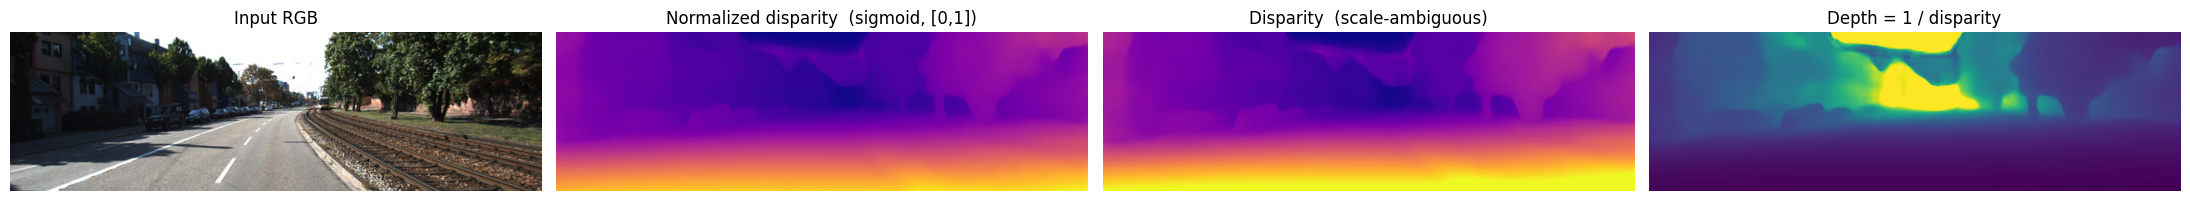

In [7]:
image_path = conf["image_path_inference"]
if not os.path.isfile(image_path):
    image_path = "src/inference/input_images/img1.jpg"
print("Image:", image_path)


img_resized, tensor, (ow, oh) = load_image(image_path)
norm_disp, disparity, depth = predict(model, tensor)


fig, axes = plt.subplots(1, 4, figsize=(22, 4))
axes[0].imshow(img_resized);                          axes[0].set_title("Input RGB")
axes[1].imshow(colorize(norm_disp, "plasma", False)); axes[1].set_title("Normalized disparity  (sigmoid, [0,1])")
axes[2].imshow(colorize(disparity, "plasma"));        axes[2].set_title("Disparity  (scale-ambiguous)")
axes[3].imshow(colorize(depth,    "viridis"));        axes[3].set_title("Depth = 1 / disparity")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Gallery: inference over the sample image folder

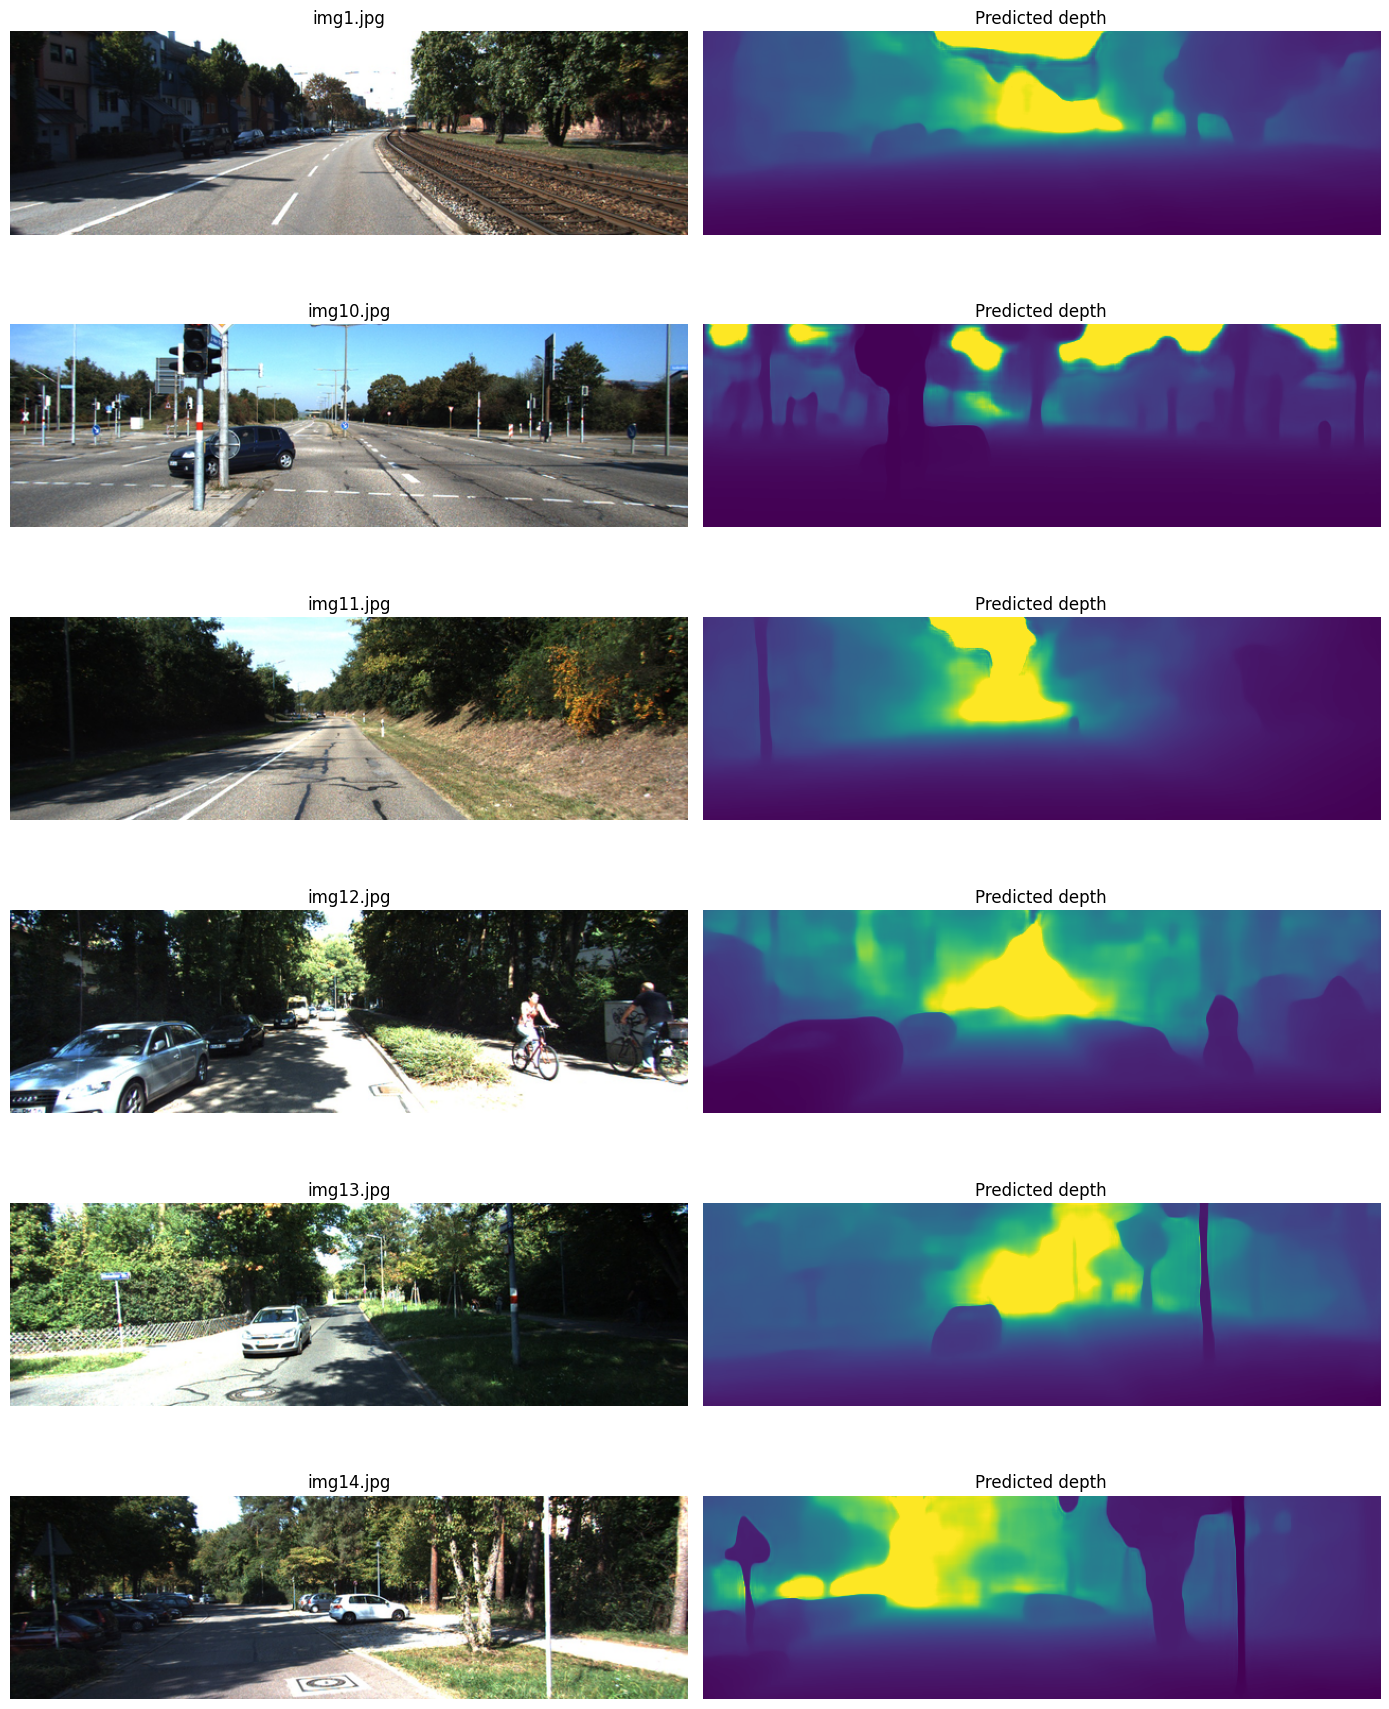

In [8]:
sample_dir = "src/inference/input_images"
paths = sorted(glob.glob(os.path.join(sample_dir, "*.jpg")))[:6]

fig, axes = plt.subplots(len(paths), 2, figsize=(14, 3.0 * len(paths)))
for row, p in enumerate(paths):
    img_r, t, _ = load_image(p)
    _, _, d = predict(model, t)
    axes[row, 0].imshow(img_r);                 axes[row, 0].set_title(os.path.basename(p))
    axes[row, 1].imshow(colorize(d, "viridis")); axes[row, 1].set_title("Predicted depth")
    axes[row, 0].axis("off"); axes[row, 1].axis("off")
plt.tight_layout(); plt.show()

## 7. JEPADepth vs. MonoDepth2 baseline



Load the classic MonoDepth2 (640x192) baseline and compare depth predictions on the same image.

In [9]:
md2 = MonoDepth2(num_layers=conf["monodepth2"]["num_layers"], pretrained=conf["monodepth2"]["pretrained"], scales=conf["monodepth2"]["scales"])
md2.from_pretrained(encoder_weights_path=conf["monodepth2"]["encoder_weights_path"], decoder_weights_path=conf["monodepth2"]["decoder_weights_path"], device=device)
md2.to(device).eval()

md2_params, _ = count_parameters(md2)
print(f"MonoDepth2 loaded  |  parameters: {format_number(md2_params)}")

MonoDepth2 loaded  |  parameters: 14.84M


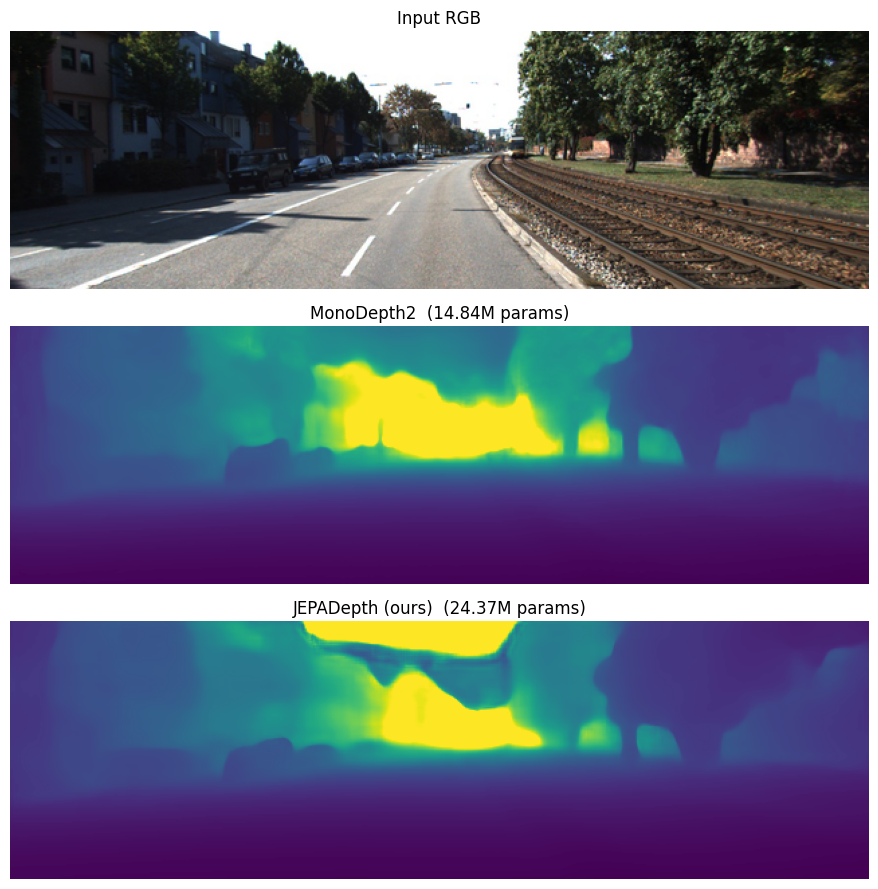

In [10]:
img_r, t, _ = load_image(image_path)
_, _, depth_jepa = predict(model, t)
_, _, depth_md2  = predict(md2,   t)


fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].imshow(img_r);                            axes[0].set_title("Input RGB")
axes[1].imshow(colorize(depth_md2,  "viridis"));  axes[1].set_title(f"MonoDepth2  ({format_number(md2_params)} params)")
axes[2].imshow(colorize(depth_jepa, "viridis"));  axes[2].set_title(f"JEPADepth (ours)  ({format_number(total_params)} params)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()